# **Install Package**

In [1]:
!pip install sentencepiece

In [2]:
import torch
import random
import numpy as np

def set_seeds(seed=42) :
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)

  if torch.cuda.is_available() :
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

  torch.backends.cudnn.deterministic= True
  torch.backends.cudnn.benchmark=False

set_seeds(42)


In [3]:
def load_pairs(path, max_samples=None) :
  pairs = []

  with open(path, encoding="utf-8") as f :
    for line in f :
        parts = line.strip().split("\t")

        if len(parts) < 2 :
          continue
        eng = parts[0].strip().lower()
        ind = parts[1].strip().lower()

        if not eng or not ind :
          continue
        pairs.append((ind, eng))

        if max_samples and len(pairs) >= max_samples :
          break
  return pairs

In [5]:
pairs = load_pairs("/content/ind.txt", max_samples=15000)
print(len(pairs))
print(pairs[:21])

15000
[('hai.', 'hi.'), ('lari!', 'run!'), ('lari!', 'run.'), ('siapa?', 'who?'), ('wow!', 'wow!'), ('wah!', 'wow!'), ('kebakaran!', 'fire!'), ('tembak!', 'fire!'), ('api!', 'fire!'), ('tolong!', 'help!'), ('lompat!', 'jump!'), ('loncat.', 'jump.'), ('berhenti!', 'stop!'), ('stop!', 'stop!'), ('tunggu!', 'wait!'), ('tunggu.', 'wait.'), ('halo.', 'hello.'), ('cepatlah!', 'hurry!'), ('cepat!', 'hurry!'), ('buruan!', 'hurry!'), ('aku mengerti.', 'i see.')]


In [6]:
random.shuffle(pairs)

split_idx = int(len(pairs) * 0.9)

train_pairs = pairs[:split_idx]
val_pairs = pairs[split_idx:]

print(f"Train : {len(train_pairs)}")
print(f"Val : {len(val_pairs)}")

Train : 13500
Val : 1500


In [7]:
import re
import unicodedata
from typing import List, Tuple

def unicode_to_ascii(s:str) -> str :
  return ''.join(
      c for c in unicodedata.normalize('NFD', s)
      if unicodedata.category(c) != 'Mn'
                )

def normalize_text(s: str) -> str :
   s= unicode_to_ascii(s.lower().strip())

   s = re.sub(r"([.!?])", r" \1",s)
   s = re.sub(r"[^a-zA-Z.!?]+", " ",s)
   s = re.sub(r"\s+", " ",s).strip()

   return s

In [8]:
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"

def add_special_tokens(target_sentence:str) -> str :
  return f"{SOS_TOKEN} {target_sentence} {EOS_TOKEN}"

def clean_paralel_pairs(pairs):
  cleaned = []

  for ind, eng in pairs :
    ind_clean = normalize_text(ind)
    eng_clean = normalize_text(eng)

    if not ind_clean or not eng_clean :
      continue
    cleaned.append((ind, eng))
  return cleaned

In [9]:
cleaned_pairs = clean_paralel_pairs(pairs)

print(f"Raw Pairs : {len(pairs)}")
print(f"Cleaned Pairs : {len(cleaned_pairs)}")
print("Sample: \n")
for i in range(min(5, len(cleaned_pairs[:-1]))) :
  print(cleaned_pairs[i])

Raw Pairs : 15000
Cleaned Pairs : 15000
Sample: 

('hanya ada sedikit makanan di dalam kulkas.', 'there is little food in the refrigerator.')
('buku-buku ini bukan hanya untuk anak-anak.', "these books aren't just for children.")
('tom tidak haus.', "tom isn't thirsty.")
('aku memberitahu tom kalau aku bisa melakukannya sendiri.', 'i told tom i could do it by myself.')
('aku suka dengan sifat optimismu.', 'i like your optimism.')


In [10]:
import sentencepiece as spm

corpus = []

for ind, eng in pairs :
  corpus.append(ind)
  corpus.append(eng)

with open("/content/sp_corpus.txt", "w", encoding="utf-8") as f :
  for line in corpus :
    f.write(line  + "\n")

spm.SentencePieceTrainer.train(
    input="/content/sp_corpus.txt",
    model_prefix="spm",
    vocab_size = 8000,
    user_defined_symbols=["<pad>","<sos>","<eos>"]
)

sp = spm.SentencePieceProcessor()
sp.load("/content/spm.model")

True

In [11]:
def tokenize(sentence) :
  return sp.encode(sentence, out_type=str)

In [12]:
from typing import List, Tuple

SPECIAL_TOKENS = [
    PAD_TOKEN,
    SOS_TOKEN,
    EOS_TOKEN,
    UNK_TOKEN
]

def add_target_tokens(sentences:str)-> str :
  return f" {SOS_TOKEN} {sentences} {EOS_TOKEN}"

def prepare_pairs(pairs: List[Tuple[str, str]]) :
  new_pairs = []

  for src, tgt in pairs :
    src_clean = src.strip()
    tgt_clean = tgt.strip()

    tgt_clean = add_target_tokens(tgt_clean)

    new_pairs.append((src_clean, tgt_clean))

  return new_pairs

def reverse_sentence(sentence:str) -> str :
  return " ".join(sentence.split()[::-1])

In [13]:
class Vocabulary :

  def __init__(self, sp):
    self.sp = sp

    self.pad_idx = sp.piece_to_id("<pad>")
    self.sos_idx = sp.piece_to_id("<sos>")
    self.eos_idx = sp.piece_to_id("<eos>")
    self.unk_idx = sp.piece_to_id("<unk>")

  def __len__(self) :
    return self.sp.get_piece_size()

  def numericalize(self, sentence) :

    if isinstance( sentence, list ) :
      sentence = " ".join(sentence)

    return self.sp.encode(sentence, out_type=int, add_bos=False, add_eos=False)

  def decode(self, ids) :
    ids = [i for i in ids if i not in [
        self.pad_idx,
        self.sos_idx,
        self.eos_idx
    ]]
    return self.sp.decode(ids)

In [14]:
if __name__ == "__main__" :
  vocab = Vocabulary(sp)

  print(f"Shared Vocab Size : {len(vocab)}")

  sample_id = "Saya Sering Kali Membuat Kodingan dengan bahasa Python"
  sample_id = normalize_text(sample_id)

  src_sentence = reverse_sentence(sample_id)

  encoded = vocab.numericalize(src_sentence)
  print("\n--- Indo -> English Example ---")
  print("Input sentence :", sample_id)
  print("Encoder input  :", src_sentence)
  print("Encoded        :", encoded)
  print("Decoded back   :", vocab.decode(encoded))

Shared Vocab Size : 8000

--- Indo -> English Example ---
Input sentence : saya sering kali membuat kodingan dengan bahasa python
Encoder input  : python bahasa dengan kodingan membuat kali sering saya
Encoded        : [507, 381, 1380, 1551, 139, 57, 3940, 155, 188, 158, 398, 430, 420, 22]
Decoded back   : python bahasa dengan kodingan membuat kali sering saya


In [15]:
print(sp.encode_as_pieces(src_sentence))

['▁p', 'y', 'th', 'on', '▁bahasa', '▁dengan', '▁ko', 'd', 'ing', 'an', '▁membuat', '▁kali', '▁sering', '▁saya']


In [16]:
from torch.utils.data import Dataset

class TranslationDataset(Dataset) :
  def __init__(self, pairs, sp) :
    self.pairs = pairs
    self.sp = sp

    self.BOS_IDX = sp.bos_id()
    self.EOS_IDX = sp.eos_id()
    self.PAD_IDX = sp.pad_id()

  def __len__(self) :
    return len(self.pairs)

  def __getitem__(self, idx) :
    src, tgt = self.pairs[idx]

    src_ids = (
        [self.BOS_IDX] +
        self.sp.encode_as_ids(src) +
        [self.EOS_IDX]
    )

    tgt_ids = self.sp.encode(tgt, return_type=int)

    decoder_input = [self.BOS_IDX] + tgt_ids

    decoder_target = tgt_ids + [self.EOS_IDX]

    return (
        torch.tensor(src_ids, dtype=torch.long),
        torch.tensor(decoder_input, dtype=torch.long),
        torch.tensor(decoder_target, dtype=torch.long)
    )

In [17]:
class Vocab :
  def __init__(self, sp) :
    self.sp = sp

    self.pad_idx = sp.piece_to_id("<pad>")
    self.sos_idx = sp.piece_to_id("<sos>")
    self.eos_idx = sp.piece_to_id("<eos>")
    self.unk_idx = sp.unk_id()

  def __len__(self) :
    return self.sp.get_piece_size()

  def numericalize(self, sentence) :

    if isinstance(sentence, list) :
      sentence = " ".join(sentence)

    ids = self.sp.encode(sentence, out_type=int)

    return ids

  def decode(self, ids) :
    clean_ids = []

    for i in ids :
      if i == self.eos_idx :
        break

      if i not in [self.pad_idx, self.sos_idx] :
        clean_ids.append(i)

    return self.sp.decode(clean_ids)

In [18]:
vocab = Vocab(sp)

print("Shared vocab size:", len(vocab))

print("\nContoh token vocab:")

for i in range(20):
    piece = sp.id_to_piece(i)
    print(i, "->", piece)

Shared vocab size: 8000

Contoh token vocab:
0 -> <unk>
1 -> <s>
2 -> </s>
3 -> <pad>
4 -> <sos>
5 -> <eos>
6 -> .
7 -> ▁tom
8 -> ?
9 -> '
10 -> ▁i
11 -> ▁aku
12 -> ▁you
13 -> ▁the
14 -> ▁is
15 -> ▁to
16 -> ▁tidak
17 -> t
18 -> ▁a
19 -> s


In [19]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch, pad_id):

    src, dec_in, dec_out = zip(*batch)
    src = pad_sequence(src, batch_first=True, padding_value=pad_id)
    dec_in = pad_sequence(dec_in, batch_first=True, padding_value=pad_id)
    dec_out = pad_sequence(dec_out, batch_first=True, padding_value=pad_id)

    return src, dec_in, dec_out

In [20]:
from torch.utils.data import DataLoader

train_dataset = TranslationDataset(train_pairs, sp)
val_dataset = TranslationDataset(val_pairs, sp)

PAD_IDX = sp.piece_to_id("<pad>")

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn= lambda x : collate_fn(x, PAD_IDX)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn= lambda x : collate_fn(x, PAD_IDX)
)

src, dec_in, dec_out = next(iter(train_loader))

print("SRC shape:", src.shape)
print("DEC IN shape:", dec_in.shape)
print("DEC OUT shape:", dec_out.shape)
print("src min:", src.min())
print("src max:", src.max())

SRC shape: torch.Size([32, 12])
DEC IN shape: torch.Size([32, 14])
DEC OUT shape: torch.Size([32, 14])
src min: tensor(1)
src max: tensor(7595)


In [21]:
src, dec_in, dec_tgt = train_dataset[0]

print("SRC IDS:", src)
print("DECODER INPUT IDS:", dec_in)
print("DECODER TARGET IDS:", dec_tgt)

print("\nSRC:", sp.decode(src.tolist()))
print("DECODER INPUT:", [sp.id_to_piece(i) for i in dec_in.tolist()])
print("DECODER TARGET:", [sp.id_to_piece(i) for i in dec_tgt.tolist()])

SRC IDS: tensor([   1,  245,   51,  471,  410,   20,  115, 2092,    6,    2])
DECODER INPUT IDS: tensor([   1,   80,   14,  399,  378,   36,   13, 2140,    6])
DECODER TARGET IDS: tensor([  80,   14,  399,  378,   36,   13, 2140,    6,    2])

SRC: hanya ada sedikit makanan di dalam kulkas.
DECODER INPUT: ['<s>', '▁there', '▁is', '▁little', '▁food', '▁in', '▁the', '▁refrigerator', '.']
DECODER TARGET: ['▁there', '▁is', '▁little', '▁food', '▁in', '▁the', '▁refrigerator', '.', '</s>']


In [22]:
print("Train dataset size:", len(train_dataset))
print("Val dataset size  :", len(val_dataset))
print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))

Train dataset size: 13500
Val dataset size  : 1500
Train batches: 422
Val batches  : 47


In [23]:
src, dec_in, dec_out = next(iter(train_loader))

for i in range(min(5, src.size(0))):

    print("\n--- SAMPLE", i, "---")

    src_ids = src[i].cpu().tolist()
    dec_in_ids = dec_in[i].cpu().tolist()
    dec_out_ids = dec_out[i].cpu().tolist()

    print("SRC IDS :", src_ids)
    print("SRC TOK :", [sp.id_to_piece(x) for x in src_ids])

    print("DEC IN IDS :", dec_in_ids)
    print("DEC IN TOK :", [sp.id_to_piece(x) for x in dec_in_ids])

    print("DEC OUT IDS :", dec_out_ids)
    print("DEC OUT TOK :", [sp.id_to_piece(x) for x in dec_out_ids])


--- SAMPLE 0 ---
SRC IDS : [1, 11, 176, 52, 103, 263, 6, 2, 3, 3, 3, 3, 3]
SRC TOK : ['<s>', '▁aku', '▁datang', '▁ke', '▁sini', '▁sendiri', '.', '</s>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']
DEC IN IDS : [1, 10, 557, 98, 76, 39, 596, 6, 3, 3, 3, 3, 3]
DEC IN TOK : ['<s>', '▁i', '▁came', '▁here', '▁on', '▁my', '▁own', '.', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']
DEC OUT IDS : [10, 557, 98, 76, 39, 596, 6, 2, 3, 3, 3, 3, 3]
DEC OUT TOK : ['▁i', '▁came', '▁here', '▁on', '▁my', '▁own', '.', '</s>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']

--- SAMPLE 1 ---
SRC IDS : [1, 7, 541, 2185, 57, 165, 22, 6, 2, 3, 3, 3, 3]
SRC TOK : ['<s>', '▁tom', '▁dulu', '▁berteman', '▁dengan', '▁anak', '▁saya', '.', '</s>', '<pad>', '<pad>', '<pad>', '<pad>']
DEC IN IDS : [1, 7, 46, 465, 87, 39, 796, 6, 3, 3, 3, 3, 3]
DEC IN TOK : ['<s>', '▁tom', '▁was', '▁friends', '▁with', '▁my', '▁son', '.', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']
DEC OUT IDS : [7, 46, 465, 87, 39, 796, 6, 2, 3, 3, 3, 3

# **Architecture Model**

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as f

In [25]:
class LSTMCell(nn.Module) :

  def __init__(self, input_size, hidden_size) :
    super().__init__()
    self.hidden_size = hidden_size

    self.W_f = nn.Linear(input_size, hidden_size)
    self.W_i = nn.Linear(input_size, hidden_size)
    self.W_c = nn.Linear(input_size, hidden_size)
    self.W_o = nn.Linear(input_size, hidden_size)

    self.U_f = nn.Linear(hidden_size, hidden_size, bias=False)
    self.U_i = nn.Linear(hidden_size, hidden_size, bias=False)
    self.U_c = nn.Linear(hidden_size, hidden_size, bias=False)
    self.U_o = nn.Linear(hidden_size, hidden_size, bias=False)

  def forward(self, x, h_prev, c_prev) :
    f_t = torch.sigmoid(self.W_f(x) + self.U_f(h_prev))
    i_t = torch.sigmoid(self.W_i(x) + self.U_i(h_prev))
    g_t = torch.tanh(self.W_c(x) + self.U_c(h_prev))
    o_t = torch.sigmoid(self.W_o(x) + self.U_o(h_prev))

    c_t = f_t * c_prev + i_t * g_t
    h_t = o_t * torch.tanh(c_t)
    return  h_t, c_t

class AdditiveAttetion(nn.Module) :

  def __init__(self, hidden_size):
    super().__init__()
    self.W_s = nn.Linear(hidden_size, hidden_size)
    self.W_h = nn.Linear(hidden_size * 2, hidden_size)
    self.v = nn.Linear(hidden_size, 1)

  def forward(self, decoder_hidden, encoder_outputs, mask) :
    batch_size, src_len, enc_dim = encoder_outputs.shape

    decoder_hidden = decoder_hidden.unsqueeze(1).repeat(1, src_len, 1)

    energy = torch.tanh(self.W_s(decoder_hidden) + self.W_h(encoder_outputs))

    scores = self.v(energy).squeeze(-1)

    scores = scores.masked_fill(mask==0, -1e9)

    attn_weight = torch.softmax(scores, dim=1)

    context = torch.bmm(attn_weight.unsqueeze(1), encoder_outputs).squeeze(1)

    return context, attn_weight

class Encoder(nn.Module)  :

  def __init__(self, vocab_size,embed_dim, hidden_size, pad_idx, num_layers=1, dropout=0.3 ) :
    super().__init__()

    self.hidden_size = hidden_size
    self.num_layers = num_layers

    self.embedding = nn.Embedding(
        vocab_size,
        embed_dim,
        padding_idx = pad_idx
    )
    self.layers = nn.ModuleList([
        LSTMCell(
            embed_dim if i == 0 else hidden_size,
            hidden_size
        )
        for i in range(num_layers)
    ])
    self.backward_layers = nn.ModuleList([
          LSTMCell(
              embed_dim if i == 0 else hidden_size,
              hidden_size
          )
          for i in range(num_layers)
      ])

    self.dropout = nn.Dropout(dropout)

  def forward(self, src):
      batch_size, seq_len = src.shape
      device = src.device
      embedded = self.dropout(self.embedding(src))

      hidden = [
          torch.zeros(batch_size, self.hidden_size, device=device)
          for _ in range(self.num_layers)
      ]

      cell = [
          torch.zeros(batch_size, self.hidden_size, device=device)
          for _ in range(self.num_layers)
      ]


      hidden_b = [
          torch.zeros(batch_size, self.hidden_size, device=device)
          for _ in range(self.num_layers)
      ]

      cell_b = [
          torch.zeros(batch_size, self.hidden_size, device=device)
          for _ in range(self.num_layers)
      ]

      encoder_outputs_f = []
      encoder_outputs_b = []


      for t in range(seq_len):
          x = embedded[:, t, :]

          for l in range(self.num_layers):

              inp = x if l == 0 else hidden[l-1]

              h, c = self.layers[l](inp, hidden[l], cell[l])

              hidden[l] = h
              cell[l] = c


          encoder_outputs_f.append(hidden[-1])

      for t in reversed(range(seq_len)):

          x = embedded[:, t, :]
          for l in range(self.num_layers):

              inp = x if l == 0 else hidden_b[l-1]

              h, c = self.backward_layers[l](inp, hidden_b[l], cell_b[l])

              hidden_b[l] = h
              cell_b[l] = c

          encoder_outputs_b.append(hidden_b[-1])


      encoder_outputs_b.reverse()


      encoder_outputs = [
          torch.cat((f, b), dim=1)
          for f, b in zip(encoder_outputs_f, encoder_outputs_b)
      ]

      encoder_outputs = torch.stack(encoder_outputs, dim=1)


      hidden = [
          torch.cat((hidden[l], hidden_b[l]), dim=1)
          for l in range(self.num_layers)
      ]


      cell = [
          torch.cat((cell[l], cell_b[l]), dim=1)
          for l in range(self.num_layers)
      ]

      return encoder_outputs, hidden, cell



class Decoder(nn.Module):

    def __init__(self, vocab_size, embed_dim, hidden_size,
                 pad_idx, num_layers=1, dropout=0.3):

        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=pad_idx
        )

        self.layers = nn.ModuleList([
            LSTMCell(
                embed_dim + hidden_size * 2 if i == 0 else hidden_size * 3,
                hidden_size
            )
            for i in range(num_layers)
        ])

        self.dropout = nn.Dropout(dropout)

        self.attention =  AdditiveAttetion(hidden_size)


        self.fc_out = nn.Linear(
            hidden_size + hidden_size * 2,
            vocab_size
        )

    def forward(self, input_token, hidden, cell,
                encoder_outputs, mask):

        input_token = input_token.unsqueeze(1)

        embedded = self.dropout(
            self.embedding(input_token).squeeze(1)
        )

        context, attn_weights = self.attention(
            hidden[-1],
            encoder_outputs,
            mask
        )

        x = torch.cat((embedded, context), dim=1)

        new_hidden = []
        new_cell = []


        h, c = self.layers[0](x, hidden[0], cell[0])

        new_hidden.append(h)
        new_cell.append(c)

        for l in range(1, self.num_layers):

            inp = torch.cat(
                (self.dropout(new_hidden[l-1]), context),
                dim=1
            )

            h, c = self.layers[l](
                inp,
                hidden[l],
                cell[l]
            )

            new_hidden.append(h)
            new_cell.append(c)

        prediction = self.fc_out(
            torch.cat(
                (self.dropout(new_hidden[-1]), context),
                dim=1
            )
        )

        return prediction, new_hidden, new_cell

class Seq2Seq(nn.Module):

    def __init__(self, encoder, decoder, pad_idx, device):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.pad_idx = pad_idx
        self.device = device

        self.bridge_hidden = nn.Linear(
            encoder.hidden_size * 2,
            decoder.hidden_size
        )

        self.bridge_cell = nn.Linear(
            encoder.hidden_size * 2,
            decoder.hidden_size
        )

    def create_mask(self, src):
        return (src != self.pad_idx)

    def forward(self, src, trg, teacher_forcing_ratio=0.5):

        batch_size = src.shape[0]
        trg_len = trg.shape[1]
        vocab_size = self.decoder.fc_out.out_features

        outputs = torch.zeros(
            batch_size,
            trg_len,
            vocab_size,
            device=self.device
        )


        mask = self.create_mask(src)


        encoder_outputs, hidden, cell = self.encoder(src)

        hidden = [
            torch.tanh(self.bridge_hidden(h))
            for h in hidden
        ]

        cell = [
            torch.tanh(self.bridge_cell(c))
            for c in cell
        ]


        input_token = trg[:, 0]


        for t in range(1, trg_len):

            output, hidden, cell = self.decoder(
                input_token,
                hidden,
                cell,
                encoder_outputs,
                mask
            )

            outputs[:, t] = output

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)

            input_token = trg[:, t] if teacher_force else top1

        return outputs

# **TRAINING MODEL**

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

VOCAB_SIZE = sp.get_piece_size()

PAD_IDX = sp.pad_id()
EMBED = 256
HIDDEN_SIZE = 512
NUM_LAYER = 2
DROPOUT = 0.3
LR = 3e-4

encoder = Encoder(
    VOCAB_SIZE,
    EMBED,
    HIDDEN_SIZE,
    PAD_IDX,
    NUM_LAYER,
    DROPOUT
)

decoder = Decoder(
    VOCAB_SIZE,
    EMBED,
    HIDDEN_SIZE,
    PAD_IDX,
    NUM_LAYER,
    DROPOUT
)

model = Seq2Seq(encoder, decoder, PAD_IDX, device).to(device)

device: cuda


In [27]:
from collections import defaultdict
import torch

def model_summary(model, optimizer=None, criterion=None, device=None):

    print("="*80)
    print("AUTO MODEL REPORT")
    print("="*80)


    print(f"Model Class        : {model.__class__.__name__}")
    print(f"Device             : {device}")
    print("-"*80)


    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"Total Parameters   : {total_params:,}")
    print(f"Trainable Params   : {trainable_params:,}")
    print(f"Non-trainable      : {total_params - trainable_params:,}")
    print("-"*80)


    print("LAYER BREAKDOWN")
    print("-"*80)

    module_params = defaultdict(int)

    for name, param in model.named_parameters():
        module_name = ".".join(name.split(".")[:2])
        module_params[module_name] += param.numel()

    for module, params in sorted(module_params.items()):
        print(f"{module:30s} {params:12,}")

    print("-"*80)


    for module in model.modules():
        if isinstance(module, torch.nn.Embedding):
            print("EMBEDDING INFO")
            print("-"*80)
            print(f"Embedding dim      : {module.embedding_dim}")
            print(f"Vocab size         : {module.num_embeddings}")
            print("-"*80)
            break


    if hasattr(model, "encoder"):
        print("ENCODER INFO")
        print("-"*80)
        print(f"Encoder Layers     : {model.encoder.num_layers}")
        print(f"Encoder Hidden     : {model.encoder.hidden_size}")
        print("-"*80)

    if hasattr(model, "decoder"):
        print("DECODER INFO")
        print("-"*80)
        print(f"Decoder Layers     : {model.decoder.num_layers}")
        print(f"Decoder Hidden     : {model.decoder.hidden_size}")
        print("-"*80)


    attention_modules = []

    for name, module in model.named_modules():
        if "attention" in name.lower():
            attention_modules.append((name, module))

    if attention_modules:
        print("ATTENTION INFO")
        print("-"*80)

        for name, attn in attention_modules:
            attn_params = sum(p.numel() for p in attn.parameters())

            print(f"Module Name        : {name}")
            print(f"Type               : {attn.__class__.__name__}")
            print(f"Parameters         : {attn_params:,}")

            for p_name, param in attn.named_parameters():
                print(f"  {p_name:25s} {param.numel():10,}")

            print("-"*80)

    if optimizer is not None:
        print("OPTIMIZER")
        print("-"*80)
        print(f"Type               : {optimizer.__class__.__name__}")
        print(f"Learning Rate      : {optimizer.param_groups[0]['lr']}")
        if 'weight_decay' in optimizer.param_groups[0]:
            print(f"Weight Decay       : {optimizer.param_groups[0]['weight_decay']}")
        print("-"*80)

    if criterion is not None:
        print("LOSS FUNCTION")
        print("-"*80)
        print(f"Type               : {criterion.__class__.__name__}")

        if hasattr(criterion, "ignore_index"):
            print(f"Ignore Index       : {criterion.ignore_index}")


        if hasattr(criterion, "label_smoothing"):
            print(f"Label Smoothing    : {criterion.label_smoothing}")

        if hasattr(criterion, "reduction"):
            print(f"Reduction          : {criterion.reduction}")

        print("-"*80)

In [28]:
batch_size = 4


x = torch.randn(batch_size, EMBED).to(device)
h = torch.zeros(batch_size, HIDDEN_SIZE).to(device)
c = torch.zeros(batch_size, HIDDEN_SIZE).to(device)

cell = LSTMCell(EMBED, HIDDEN_SIZE).to(device)

h_new, c_new = cell(x, h, c)

print("x:", x.shape)
print("h_new:", h_new.shape)
print("c_new:", c_new.shape)

x: torch.Size([4, 256])
h_new: torch.Size([4, 512])
c_new: torch.Size([4, 512])


In [29]:
BATCH = 4
SRC_LEN = 10
VOCAB_SIZE = sp.get_piece_size()
PAD_IDX = sp.piece_to_id("<pad>")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

src = torch.randint(0, VOCAB_SIZE, (BATCH, SRC_LEN)).to(device)

input_token = torch.randint(0, VOCAB_SIZE, (BATCH,)).to(device)

encoder_outputs, hidden, cell = encoder(src)

hidden = [
    torch.tanh(model.bridge_hidden(h))
    for h in hidden
]

cell = [
    torch.tanh(model.bridge_cell(c))
    for c in cell
]

mask = (src != PAD_IDX)

output, h_new, c_new = decoder(
    input_token,
    hidden,
    cell,
    encoder_outputs,
    mask
)

print("encoder_outputs:", encoder_outputs.shape)
print("decoder output:", output.shape)

encoder_outputs: torch.Size([4, 10, 1024])
decoder output: torch.Size([4, 8000])


In [30]:
encoder = Encoder(VOCAB_SIZE, EMBED, HIDDEN_SIZE, PAD_IDX).to(device)
decoder = Decoder(VOCAB_SIZE, EMBED, HIDDEN_SIZE, PAD_IDX).to(device)

bridge_hidden = nn.Linear(HIDDEN_SIZE * 2, HIDDEN_SIZE).to(device)
bridge_cell = nn.Linear(HIDDEN_SIZE * 2, HIDDEN_SIZE).to(device)

src = torch.randint(0, VOCAB_SIZE, (BATCH, SRC_LEN)).to(device)
input_token = torch.randint(0, VOCAB_SIZE, (BATCH,)).to(device)

encoder_outputs, hidden, cell = encoder(src)

hidden = [torch.tanh(bridge_hidden(h)) for h in hidden]
cell   = [torch.tanh(bridge_cell(c)) for c in cell]

mask = (src != PAD_IDX)

output, h_new, c_new = decoder(
    input_token,
    hidden,
    cell,
    encoder_outputs,
    mask
)

print("decoder output:", output.shape)

decoder output: torch.Size([4, 8000])


In [31]:
BATCH = 4
SRC_LEN = 10

encoder = Encoder(VOCAB_SIZE, EMBED, HIDDEN_SIZE, PAD_IDX).to(device)
decoder = Decoder(VOCAB_SIZE, EMBED, HIDDEN_SIZE, PAD_IDX).to(device)

bridge_hidden = nn.Linear(HIDDEN_SIZE * 2, HIDDEN_SIZE).to(device)
bridge_cell = nn.Linear(HIDDEN_SIZE * 2, HIDDEN_SIZE).to(device)

src = torch.randint(0, VOCAB_SIZE, (BATCH, SRC_LEN)).to(device)

input_token = torch.randint(0, VOCAB_SIZE, (BATCH,)).to(device)

encoder_outputs, hidden, cell = encoder(src)
hidden = [torch.tanh(bridge_hidden(h)) for h in hidden]
cell   = [torch.tanh(bridge_cell(c)) for c in cell]

mask = (src != PAD_IDX)

output, h_new, c_new = decoder(
    input_token,
    hidden,
    cell,
    encoder_outputs,
    mask
)

print("encoder_outputs:", encoder_outputs.shape)
print("decoder output:", output.shape)

encoder_outputs: torch.Size([4, 10, 1024])
decoder output: torch.Size([4, 8000])


In [32]:
criterion = torch.nn.CrossEntropyLoss(ignore_index=PAD_IDX,
                                      label_smoothing=0.05)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr = LR,
    weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

In [33]:
model_summary(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    device=device
)

AUTO MODEL REPORT
Model Class        : Seq2Seq
Device             : cuda
--------------------------------------------------------------------------------
Total Parameters   : 33,446,209
Trainable Params   : 33,446,209
Non-trainable      : 0
--------------------------------------------------------------------------------
LAYER BREAKDOWN
--------------------------------------------------------------------------------
bridge_cell.bias                        512
bridge_cell.weight                  524,288
bridge_hidden.bias                      512
bridge_hidden.weight                524,288
decoder.attention                   787,969
decoder.embedding                 2,048,000
decoder.fc_out                   12,296,000
decoder.layers                    7,868,416
encoder.backward_layers           3,674,112
encoder.embedding                 2,048,000
encoder.layers                    3,674,112
--------------------------------------------------------------------------------
EMBEDDING INFO
-

In [34]:
model.eval()

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(8000, 256, padding_idx=7999)
    (layers): ModuleList(
      (0): LSTMCell(
        (W_f): Linear(in_features=256, out_features=512, bias=True)
        (W_i): Linear(in_features=256, out_features=512, bias=True)
        (W_c): Linear(in_features=256, out_features=512, bias=True)
        (W_o): Linear(in_features=256, out_features=512, bias=True)
        (U_f): Linear(in_features=512, out_features=512, bias=False)
        (U_i): Linear(in_features=512, out_features=512, bias=False)
        (U_c): Linear(in_features=512, out_features=512, bias=False)
        (U_o): Linear(in_features=512, out_features=512, bias=False)
      )
      (1): LSTMCell(
        (W_f): Linear(in_features=512, out_features=512, bias=True)
        (W_i): Linear(in_features=512, out_features=512, bias=True)
        (W_c): Linear(in_features=512, out_features=512, bias=True)
        (W_o): Linear(in_features=512, out_features=512, bias=True)
        (U_f): Li

In [35]:
def get_grad_norm(model):

    total_norm = 0.0

    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(2)
            total_norm += param_norm.item() ** 2

    total_norm = total_norm ** 0.5
    return total_norm


def train_epoch(model, loader, optimizer, criterion, device, teacher_forcing_ratio):

    model.train()
    total_loss = 0
    total_tokens = 0
    total_grad = 0

    for src, dec_in, dec_out in loader:

        src = src.to(device)
        dec_in = dec_in.to(device)
        dec_out = dec_out.to(device)

        optimizer.zero_grad()

        output = model(src, dec_in, teacher_forcing_ratio)

        output = output.reshape(-1, output.size(-1))
        dec_out = dec_out.reshape(-1)

        loss = criterion(output, dec_out)

        non_pad = dec_out != PAD_IDX
        num_tokens = non_pad.sum().item()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        grad_norm = get_grad_norm(model)
        total_grad += grad_norm

        optimizer.step()

        total_loss += loss.item()
        total_tokens += num_tokens

    avg_loss = total_loss / total_tokens

    avg_grad = total_grad / len(loader)

    return avg_loss, avg_grad


def eval_epoch(model, loader, criterion, device):

    model.eval()
    total_loss = 0
    total_tokens = 0

    with torch.no_grad():

        for src, dec_in, dec_out in loader:

            src = src.to(device)
            dec_in = dec_in.to(device)
            dec_out = dec_out.to(device)

            output = model(src, dec_in, 0.0)

            output = output.reshape(-1, output.size(-1))
            dec_out = dec_out.reshape(-1)

            loss = criterion(output, dec_out)

            non_pad = dec_out != PAD_IDX
            total_tokens += non_pad.sum().item()

            total_loss += loss.item()

    return total_loss / total_tokens

In [36]:
import time

loss_history = []
val_history = []
grad_history = []

num_epochs = 5
best_val = float('inf')

patience = 3
patience_counter = 0

start_training_time = time.time()

for epoch in range(num_epochs):

    teacher_forcing_ratio = max(
        0.2,
        1.0 - epoch * 0.02
    )

    epoch_start_time = time.time()

    train_loss, train_grad = train_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device,
        teacher_forcing_ratio
    )
    val_loss = eval_epoch(
        model,
        val_loader,
        criterion,
        device,
    )

    scheduler.step(val_loss)

    loss_history.append(train_loss)
    val_history.append(val_loss)
    grad_history.append(train_grad)

    if val_loss < best_val:
        best_val = val_loss
        torch.save({
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "epoch": epoch,
            "val_loss": val_loss
        }, "best_seq2seq.pt")
        print("Best model saved")
        patience_counter = 0
    else:
        patience_counter += 1

    epoch_time = time.time() - epoch_start_time

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Grad Norm  : {train_grad:.4f}")
    print(f"Epoch Time : {epoch_time:.2f} sec")
    print(f"Patience   : {patience_counter}/{patience}")
    print(f"Teacher Forcing : {teacher_forcing_ratio:.2f}")
    print(f"LR         : {optimizer.param_groups[0]['lr']:.6f}")
    print("-"*40)

    if patience_counter >= patience:
        print("Early stopping triggered!")
        break

total_time = time.time() - start_training_time
print(f"\nTotal Training Time: {total_time:.2f} sec")

Best model saved

Epoch 1
Train Loss : 0.0216
Val Loss   : 0.0209
Grad Norm  : 0.9358
Epoch Time : 77.59 sec
Patience   : 0/3
Teacher Forcing : 1.00
LR         : 0.000300
----------------------------------------
Best model saved

Epoch 2
Train Loss : 0.0193
Val Loss   : 0.0204
Grad Norm  : 0.9686
Epoch Time : 81.39 sec
Patience   : 0/3
Teacher Forcing : 0.98
LR         : 0.000300
----------------------------------------
Best model saved

Epoch 3
Train Loss : 0.0181
Val Loss   : 0.0196
Grad Norm  : 0.9999
Epoch Time : 84.54 sec
Patience   : 0/3
Teacher Forcing : 0.96
LR         : 0.000300
----------------------------------------
Best model saved

Epoch 4
Train Loss : 0.0171
Val Loss   : 0.0190
Grad Norm  : 1.0000
Epoch Time : 81.76 sec
Patience   : 0/3
Teacher Forcing : 0.94
LR         : 0.000300
----------------------------------------
Best model saved

Epoch 5
Train Loss : 0.0163
Val Loss   : 0.0186
Grad Norm  : 1.0000
Epoch Time : 82.19 sec
Patience   : 0/3
Teacher Forcing : 0.92
LR 

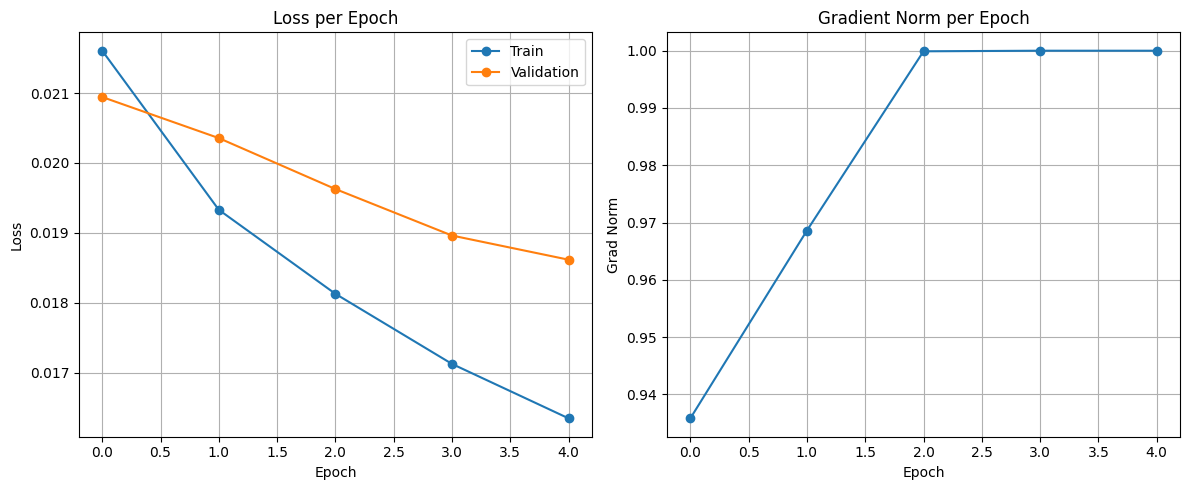

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))


plt.subplot(1,2,1)

plt.plot(loss_history, marker='o', label="Train")
plt.plot(val_history, marker='o', label="Validation")

plt.title("Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()



plt.subplot(1,2,2)

plt.plot(grad_history, marker='o')

plt.title("Gradient Norm per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Grad Norm")
plt.grid()


plt.tight_layout()
plt.show()

In [38]:
checkpoint = torch.load("best_seq2seq.pt", map_location=device)

model.load_state_dict(checkpoint["model"])

model.eval()

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(8000, 256, padding_idx=7999)
    (layers): ModuleList(
      (0): LSTMCell(
        (W_f): Linear(in_features=256, out_features=512, bias=True)
        (W_i): Linear(in_features=256, out_features=512, bias=True)
        (W_c): Linear(in_features=256, out_features=512, bias=True)
        (W_o): Linear(in_features=256, out_features=512, bias=True)
        (U_f): Linear(in_features=512, out_features=512, bias=False)
        (U_i): Linear(in_features=512, out_features=512, bias=False)
        (U_c): Linear(in_features=512, out_features=512, bias=False)
        (U_o): Linear(in_features=512, out_features=512, bias=False)
      )
      (1): LSTMCell(
        (W_f): Linear(in_features=512, out_features=512, bias=True)
        (W_i): Linear(in_features=512, out_features=512, bias=True)
        (W_c): Linear(in_features=512, out_features=512, bias=True)
        (W_o): Linear(in_features=512, out_features=512, bias=True)
        (U_f): Li

In [39]:
def translate_beam(model,sentence,sp,device,beam_size=3,max_len=50,alpha=0.7,reverse_src=True):

    model.eval()

    sos_id = sp.piece_to_id("<sos>")
    eos_id = sp.piece_to_id("<eos>")

    print("SOS:", sos_id, sp.id_to_piece(sos_id))
    print("EOS:", eos_id, sp.id_to_piece(eos_id))

    if reverse_src:
        sentence = " ".join(sentence.split()[::-1])

    print("INPUT SENTENCE:", sentence)

    src_ids = [sos_id] + sp.encode(sentence, out_type=int) + [eos_id]

    print("SRC IDS:", src_ids)
    print("SRC TOK:", [sp.id_to_piece(i) for i in src_ids])

    src = torch.tensor(src_ids).unsqueeze(0).to(device)


    with torch.no_grad():

        encoder_outputs, hidden, cell = model.encoder(src)

        hidden = [
            torch.tanh(model.bridge_hidden(h))
            for h in hidden
        ]

        cell = [
            torch.tanh(model.bridge_cell(c))
            for c in cell
        ]


    mask = model.create_mask(src)


    beams = [([sos_id], 0.0, hidden, cell)]

    for step in range(max_len):

        new_beams = []
        all_finished = True

        for seq, score, h_state, c_state in beams:


            if seq[-1] == eos_id:
                new_beams.append((seq, score, h_state, c_state))
                continue

            all_finished = False

            input_token = torch.tensor([seq[-1]]).to(device)


            with torch.no_grad():

                output, new_hidden, new_cell = model.decoder(
                    input_token,
                    h_state,
                    c_state,
                    encoder_outputs,
                    mask
                )

            log_probs = torch.log_softmax(output, dim=-1)


            topk = torch.topk(log_probs, beam_size)

            for k in range(beam_size):

                token = topk.indices[0][k].item()
                token_log_prob = topk.values[0][k].item()

                new_seq = seq + [token]


                length = len(new_seq)
                new_score = (score + token_log_prob) / (length ** alpha)


                hidden_clone = [h.clone() for h in new_hidden]
                cell_clone = [c.clone() for c in new_cell]

                new_beams.append(
                    (new_seq, new_score, hidden_clone, cell_clone)
                )


        if all_finished:
            break


        beams = sorted(
            new_beams,
            key=lambda x: x[1],
            reverse=True
        )[:beam_size]

    best_seq = beams[0][0]

    best_seq = best_seq[1:]


    if eos_id in best_seq:
        best_seq = best_seq[:best_seq.index(eos_id)]

    print("OUTPUT IDS:", best_seq)
    print("OUTPUT TOK:", [sp.id_to_piece(i) for i in best_seq])

    return sp.decode(best_seq)

In [40]:
sentences = [
    "saya suka makan",
    "saya suka makan nasi",
    "saya makan nasi goreng",
    "dia pergi ke sekolah",
    "kami sedang belajar bahasa inggris",
    "saya minum kopi setiap pagi",
    "mereka bermain sepak bola",
    "saya pergi ke pasar pagi ini",
    "dia membeli buku baru kemarin",
    "kami akan pergi liburan minggu depan",
    "saya ingin belajar machine learning",
    "mereka sedang menonton film di rumah",
    "saya suka makan nasi goreng di malam hari",
    "dia tidak datang ke kantor hari ini",
    "kami sedang mengerjakan proyek bersama",
    "mereka belajar bahasa baru setiap hari",
    "saya ingin pergi ke bandung akhir pekan ini",
    "saya makan mie",
    "saya makan roti",
    "dia sedang membaca buku"
]

for s in sentences:
    result = translate_beam(model, s, sp, device)
    print(f"ID : {s}")
    print(f"EN : {result}")
    print("-" * 50)

SOS: 4 <sos>
EOS: 5 <eos>
INPUT SENTENCE: makan suka saya
SRC IDS: [4, 97, 73, 22, 5]
SRC TOK: ['<sos>', '▁makan', '▁suka', '▁saya', '<eos>']
OUTPUT IDS: [12, 160, 2, 6, 2, 2, 2, 2, 2, 8, 2, 160, 8, 160, 160, 8, 2, 2, 8, 2, 2, 2, 8, 2, 2, 8, 2, 8, 2, 2, 8, 2, 2, 8, 2, 2, 2, 8, 2, 2, 8, 2, 2, 8, 2, 2, 8, 2, 2, 2]
OUTPUT TOK: ['▁you', '▁eat', '</s>', '.', '</s>', '</s>', '</s>', '</s>', '</s>', '?', '</s>', '▁eat', '?', '▁eat', '▁eat', '?', '</s>', '</s>', '?', '</s>', '</s>', '</s>', '?', '</s>', '</s>', '?', '</s>', '?', '</s>', '</s>', '?', '</s>', '</s>', '?', '</s>', '</s>', '</s>', '?', '</s>', '</s>', '?', '</s>', '</s>', '?', '</s>', '</s>', '?', '</s>', '</s>', '</s>']
ID : saya suka makan
EN : you eat.? eat? eat eat???????????
--------------------------------------------------
SOS: 4 <sos>
EOS: 5 <eos>
INPUT SENTENCE: nasi makan suka saya
SRC IDS: [4, 833, 97, 73, 22, 5]
SRC TOK: ['<sos>', '▁nasi', '▁makan', '▁suka', '▁saya', '<eos>']
OUTPUT IDS: [10, 44, 15, 6, 6, 6, 2, 2, 2, 